## Satellite snapshots for Jill Pelto collab

In [1]:
## import required packages
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cmocean
from pyproj import Proj, Transformer
import glob
import os
import string
from datetime import datetime
import scipy.io as sio

In [2]:
from dask.distributed import Client

client = Client("tcp://127.0.0.1:39215")
client

<Client: 'tcp://127.0.0.1:39215' processes=8 threads=32, memory=123.95 GiB>

In [3]:
# Set data directory and load all matching NetCDF files
data_dir = "/home/jpluser/efs-mount-point/mzahn/satellite_data/sic_nsidc_cdr"
sic_file_paths_2022 = sorted(glob.glob(os.path.join(data_dir, "sic_psn25_202209*_F17_v05r00.nc")))

data_dir = "/home/jpluser/efs-mount-point/mzahn/satellite_data/sss_rss_smap"
sss_file_paths_2022 = sorted(glob.glob(os.path.join(data_dir, "*2022*.nc")))

In [4]:
# open Sept 2022 SIC files
sic_sept_da = xr.open_mfdataset(sic_file_paths_2022,combine='by_coords')

In [5]:
sic_sept_snap = sic_sept_da.cdr_seaice_conc.sel(time='2022-09-25')

In [6]:
# sss is reported in DOY not mon/day
dates = ['20220925']
for date_str in dates:
    dt = datetime.strptime(date_str, '%Y%m%d')
    doy = dt.timetuple().tm_yday
    print(f"{date_str} -> DOY {doy}")

20220925 -> DOY 268


In [7]:
# The SMAP radiometer was put in safehold mode during Julian days 218 – 265 (06 AUG – 21
# SEP) in 2022. No L2C and 8-day L3 files are available during this time period. No monthly L3
# files are produced for AUG – SEP 2022
len(sss_file_paths_2022)

317

In [8]:
# select specific dates for fig 1
sss_file_paths = [[item for item in sss_file_paths_2022 if '2022_268' in item][0]]

In [9]:
# open snapshot for sept 23
sss_sept_snap = xr.open_dataset(sss_file_paths[0])

In [10]:
def remap_colormap(cmap, nonlin_scale=np.sqrt, n=256):
    """
    Remap a colormap so that lower values are compressed (darker colors take up less space),
    and higher values (lighter colors) are stretched out.
    
    Parameters:
    - cmap: The original colormap (e.g., cmocean.cm.ice)
    - nonlin_scale: A function that maps [0,1] -> [0,1] nonlinearly (default: np.sqrt)
    - n: Number of color levels
    
    Returns:
    - A new colormap with redistributed colors.
    """
    # Generate linearly spaced values, then apply non-linear scaling
    orig_vals = np.linspace(0, 1, n)
    remapped_vals = nonlin_scale(orig_vals)

    # Normalize remapped values to stay in [0,1]
    remapped_vals = (remapped_vals - remapped_vals.min()) / (remapped_vals.max() - remapped_vals.min())

    # Map those values through the original colormap
    new_colors = cmap(remapped_vals)
    
    return LinearSegmentedColormap.from_list(f'remapped_{cmap.name}', new_colors, N=n)

In [11]:
from matplotlib.colors import LinearSegmentedColormap

# create a nonlinearly adjusted colormap from the cmocean ice colormap
custom_ice_cmap = remap_colormap(cmocean.cm.ice, nonlin_scale=np.sqrt)  # sqrt compresses low end

Map of area

In [12]:
sss = sss_sept_snap.sss_smap

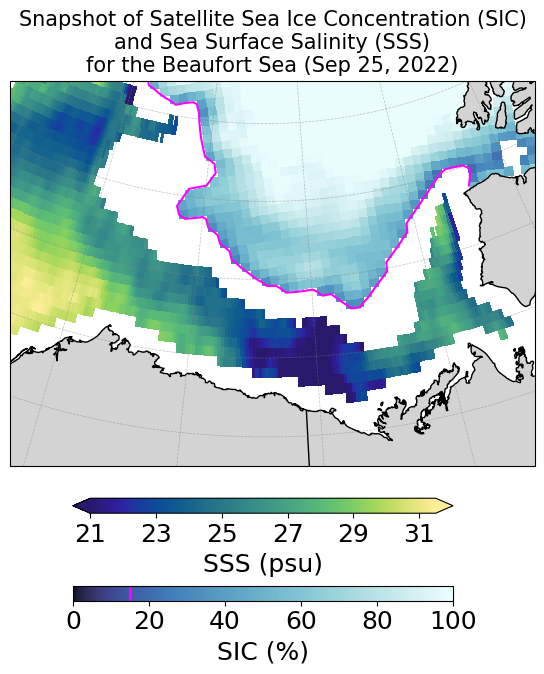

In [20]:
plt.rcParams['font.size'] = 18

# Define NSIDC stereographic projection
nsidc_proj = Proj(proj='stere', lat_0=90, lon_0=-45, lat_ts=70,
                  a=6378273, b=6356889.449, units='m')
transformer = Transformer.from_proj(nsidc_proj, "epsg:4326", always_xy=True)

# Create single plot
fig, ax = plt.subplots(1, 1, figsize=(7.6, 5),subplot_kw={'projection': ccrs.NorthPolarStereo(central_longitude=-144)})

# --- Load and process data for the first file ---
sic_masked = sic_sept_snap.where(sic_sept_snap > 0.15)

# Get grid and lat/lon
x = sic_sept_snap['x'].values
y = sic_sept_snap['y'].values
X, Y = np.meshgrid(x, y)
lon, lat = transformer.transform(X, Y)

# Define title with date
dt = pd.to_datetime(sic_sept_snap['time'].values)
date_str = dt.strftime('%b %d, %Y')
title = f"Snapshot of Satellite Sea Ice Concentration (SIC)\nand Sea Surface Salinity (SSS)\nfor the Beaufort Sea ({date_str})"

# Plot
ax.set_extent([-161, -126, 67.5, 77.5], crs=ccrs.PlateCarree())
ax.add_feature(cfeature.NaturalEarthFeature('physical', 'land', '10m', facecolor='lightgray'))
ax.add_feature(cfeature.BORDERS.with_scale('10m'))
ax.add_feature(cfeature.COASTLINE.with_scale('10m'))
gl = ax.gridlines(draw_labels=False, linewidth=0.5, color='gray',
                  alpha=0.5, linestyle='--', ylocs=[67, 69, 71, 73, 75, 77, 79])

# Plot SSS
sss_cb = sss.plot(ax=ax, transform=ccrs.PlateCarree(), cmap=cmocean.cm.haline,
                  vmin=21, vmax=31.5, add_colorbar=False, extend='both')

# Overlay SIC
sic_cb = ax.pcolormesh(lon, lat, sic_masked.squeeze() * 100, transform=ccrs.PlateCarree(),
                       cmap=custom_ice_cmap, shading='auto', vmin=0, vmax=100)

# Add 15% contour
regional_mask = ((lon >= -165) & (lon <= -120) & (lat >= 66) & (lat <= 80))
sic_region = np.where(regional_mask, sic_sept_snap.squeeze(), np.nan)
ax.contour(lon, lat, sic_region * 100, levels=[15], colors='magenta',
           linewidths=1.5, transform=ccrs.PlateCarree())

ax.set_title(title, fontsize=15)

# --- Colorbars ---
# SSS colorbar
cbar_ax_sss = fig.add_axes([0.25, 0.015, 0.5, 0.03])  # [left, bottom, width, height]
cb_sss = fig.colorbar(sss_cb, cax=cbar_ax_sss, orientation='horizontal', extend='both')
cb_sss.set_label('SSS (psu)')
cb_sss.set_ticks([21, 23, 25, 27, 29, 31])

# SIC colorbar
cbar_ax_sic = fig.add_axes([0.25, -0.16, 0.5, 0.03])
cb_sic = fig.colorbar(sic_cb, cax=cbar_ax_sic, orientation='horizontal')
cb_sic.set_label('SIC (%)')
cb_sic.ax.vlines(15, *cb_sic.ax.get_xlim(), colors='magenta', linewidth=2)

plt.savefig('sss_sic_snapshot_beaufort.png', dpi=300, bbox_inches='tight')
plt.show()

## Plot astrid data

In [13]:
# --- Load .mat file ---
mat = sio.loadmat('/home/jpluser/efs-mount-point/mzahn/satellite_data/AstridIceProduct.mat')

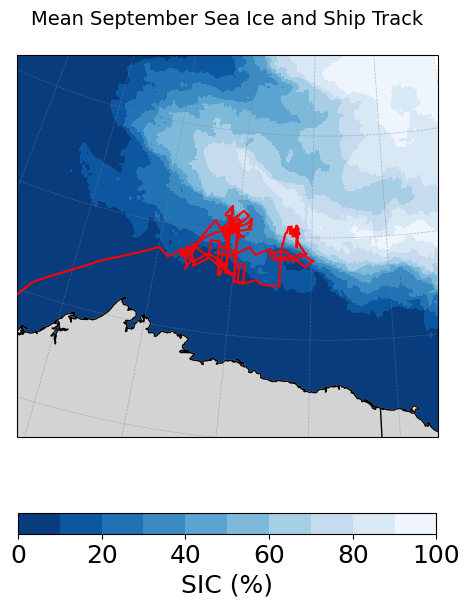

In [19]:
plt.rcParams['font.size'] = 18

# Extract variables
ice_lat = mat['ice_lat_grid']
ice_lon = mat['ice_lon_grid']
mean_ice = mat['meanSeptIce']
lat_ship = mat['lat_ship'].squeeze()
lon_ship = mat['lon_ship'].squeeze()

# --- Create map ---
fig, ax = plt.subplots(subplot_kw={'projection': ccrs.NorthPolarStereo(central_longitude=-144)}, figsize=(9, 7))

# Match extent and style to your Beaufort Sea figure
ax.set_extent([-161, -138, 69, 76], crs=ccrs.PlateCarree())

# --- Plot mean September ice ---
pcm = ax.contourf(
    ice_lon, ice_lat, mean_ice,
    transform=ccrs.PlateCarree(),
    cmap='Blues_r',
    levels=10
)

# Overlay ship track points
ax.plot(
    lon_ship, lat_ship,
    color='r',
    transform=ccrs.PlateCarree(),
    zorder=3
)

# Add map features
ax.add_feature(cfeature.LAND, color='lightgray', zorder=1)
ax.add_feature(cfeature.COASTLINE.with_scale('10m'))
ax.add_feature(cfeature.BORDERS.with_scale('10m'))
gl = ax.gridlines(draw_labels=False, linewidth=0.5, color='gray',
                  alpha=0.5, linestyle='--', ylocs=[67, 69, 71, 73, 75, 77, 79])

# Add colorbar and title
plt.colorbar(pcm, ax=ax, orientation='horizontal', label='SIC (%)', pad=0.14, shrink=0.6)
ax.set_title('Mean September Sea Ice and Ship Track\n', fontsize=14)

plt.savefig('Ice_map_and_ship_track.png', dpi=300, bbox_inches='tight')
plt.show()